# eBPF Bottleneck Classifier v7 — Binary High-Severity Detection, Test-First Diagnostics

**Built on the v6 champion:** SMOTE + Random Forest, 3-class (Normal/Medium/High), Macro F1 = 0.690, Accuracy = 0.856.
The v6 confusion matrix showed the errors are *not* evenly spread — Medium↔Normal confusion (9,221 + 6,595 rows)
dwarfs Medium↔High confusion (966 + 358 rows), and Medium recall (0.380) is the weak link. High itself is already
reasonably separated (recall 0.763, precision 0.69).

Since the stated goal is **accurately detecting the High severity class** specifically, v7 reframes the problem as
**binary: High vs. not-High**, and spends its effort on the levers that the v6 confusion matrix says actually matter
for that goal — threshold calibration, decision-threshold tuning on `predict_proba`, and a robustness check —
rather than a generic re-run of the same pipeline.

| Section | Addresses |
|---|---|
| 1 | Rebuild the leakage-free feature set (carried over from v6, unchanged) |
| **TEST 1** | **Threshold calibration grid** — percentile ladder + candidate `HIGH_THRESHOLD_NS` grid, eyeball before hardcoding |
| 2 | Binary label derivation (High vs. not-High) using the calibrated threshold |
| **TEST 2** | **Binary vs. 3-class check** — does binary framing beat v6's isolated High precision/recall? |
| **TEST 3** | **Decision-threshold sweep** — precision/recall trade-off on `predict_proba`, before picking a deployment cutoff |
| **TEST 4** | **Boundary-zone feature audit** — do near-boundary "not-High" rows actually look like High on `cpu_migrations` / `runtime_per_switch`? |
| 3 | Stratified train/test split (frozen) |
| 4 | Class imbalance: baseline vs `class_weight` vs SMOTE vs Borderline-SMOTE vs ADASYN (binary) |
| 5 | Stratified k-fold CV robustness check on the champion (single-split can be split-lucky) |
| 6 | Light hyperparameter search (only after imbalance/threshold fixes) |
| 7 | Feature importance: impurity vs permutation vs SHAP |
| 8 | Final decision-threshold tuning + confusion matrix + misclassified-sample inspection |
| 9 | Final comparison, champion selection, artifact saving |

**Rules carried over from v6:**
- Resampling and scaling are fit **only** on `X_train`/`y_train`, never on the test set.
- No features dropped on Pearson correlation alone; importance triangulated across impurity, permutation, and SHAP.
- Evaluation reports **High-class precision/recall/F1** and **PR-AUC**, not just accuracy — accuracy on an
  imbalanced binary problem is close to meaningless here (predicting "not-High" for everything gets ~95%+).

**Note on scope vs. v6:** v6's `MLPClassifier` comparison is dropped in v7 — it wasn't part of the specific
improvements this notebook targets, and tree ensembles were already the stronger, scale-invariant performer in v6.
If you want it back, Section 4's champion selection is a drop-in point.

**A note on execution:** this notebook was authored without access to `perf_metrics1.csv` / `perf_metrics2.csv`
(they live in your environment, not this one), so it has **not been run** — no cell outputs are baked in. Run it
top to bottom in your own environment, and stop to actually read the four TEST cells before letting the rest of
the pipeline proceed, per your request.

---
# Section 1 — Load & Rebuild the Leakage-Free Feature Set

Unchanged from v6. If you already have `df` with `FEATURE_COLS` in memory, you can skip to **TEST CELL 1**.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import gc
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support, f1_score, accuracy_score,
    precision_recall_curve, average_precision_score, roc_auc_score, make_scorer
)

pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

RANDOM_STATE = 42

In [2]:
# -- Load multiple CSV parts (manually named, no auto-discovery) --------------
CSV_PARTS = [
    'perf_metrics1.csv',
    'perf_metrics2.csv',
    # add more here as you collect them
]
# -------------------------------------------------------------------------------

dfs = []
for path in CSV_PARTS:
    if not os.path.exists(path):
        print(f"  skipping (not found): {path}")
        continue
    part = pd.read_csv(path)
    part['source_file'] = path
    dfs.append(part)
    print(f"  loaded {path:<20}: {len(part):>8} rows")

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nCombined shape: {df_raw.shape}")
print(f"Sessions found : {df_raw['session_label'].unique().tolist()}")
df_raw['session_label'].value_counts()

  loaded perf_metrics1.csv   :   526895 rows
  loaded perf_metrics2.csv   :   250683 rows

Combined shape: (777578, 45)
Sessions found : ['idle', 'cpu_low', 'cpu_medium', 'cpu_high', 'cpu_overloaded', 'mem_low', 'mem_high', 'io_low', 'lock_low', 'mixed_load', 'cpu_extreme', 'cpu_ultra', 'mem_extreme', 'mem_thrashing', 'cpu_mem_extreme', 'cpu_mem_ultra', 'io_extreme', 'cpu_io_extreme', 'lock_extreme', 'lock_cpu_mix', 'everything_max', 'everything_insane', 'cpu_2x', 'cpu_4x', 'cpu_8x', 'mem_reclaim', 'mem_heavy_reclaim', 'cpu_mem_2x', 'cpu_mem_4x', 'cpu_mem_8x', 'cpu_mem_io', 'cpu_mem_io_heavy', 'lock_heavy', 'lock_cpu_heavy', 'everything_extreme', 'compile_only', 'compile_sysbench', 'compile_blender', 'full_system', 'mem_swap_thrashing', 'cpu_l3_cache_misses', 'mem_swap_thrash', 'mem_tlb_cache_miss', 'io_async_saturation', 'ctx_flood', 'llm_inference', 'ml_training', 'stream_memory_contention', 'cache_contention', 'context_switch_contention']


session_label
stream_memory_contention     146855
cache_contention             133428
context_switch_contention    121529
llm_inference                 39621
everything_max                21993
ml_training                   21422
everything_insane             20568
lock_cpu_heavy                11752
cpu_8x                        10213
lock_low                      10112
lock_heavy                     9933
everything_extreme             9705
cpu_mem_io                     9449
cpu_medium                     9261
full_system                    8964
cpu_low                        8331
cpu_mem_io_heavy               8082
cpu_mem_4x                     8024
cpu_mem_8x                     7969
mem_low                        7914
mem_extreme                    7764
mem_reclaim                    7449
compile_only                   6823
cpu_mem_2x                     6718
io_low                         6653
compile_sysbench               6585
compile_blender                6570
mem_tlb_cache_

In [3]:
# -- CLEANING (same rules as v6) -----------------------------------------------
df = df_raw.copy()
before = len(df)

df = df[df['pid'] > 0]
df = df[df['ctx_switches'] > 0]
df = df[df['latency_count'] > 0]

print(f"Cleaned: {before} -> {len(df)} rows ({before - len(df)} removed)")

Cleaned: 777578 -> 664256 rows (113322 removed)


In [4]:
# -- FEATURE ENGINEERING (causal signals only -- same as v6) ------------------
df['involuntary_ratio']  = df['involuntary_switches'] / df['ctx_switches'].clip(lower=1)
df['voluntary_ratio']    = df['voluntary_switches']   / df['ctx_switches'].clip(lower=1)
df['runtime_per_switch'] = df['total_runtime_ns']     / df['ctx_switches'].clip(lower=1)
df['read_write_ratio']   = df['read_bytes'] / (df['write_bytes'] + 1)
df['io_bytes_total']     = df['read_bytes'] + df['write_bytes']
df['alloc_pressure']     = df['total_alloc_bytes'] / df['ctx_switches'].clip(lower=1)
df['lock_pressure']      = (
    df['mutex_contentions'] + df['rwsem_read_contentions'] + df['rwsem_write_contentions']
)

log_cols = ['total_runtime_ns', 'avg_syscall_latency_ns', 'max_syscall_latency_ns',
            'io_bytes_total', 'total_alloc_bytes']
for col in log_cols:
    if col in df.columns:
        df[f'log_{col}'] = np.log1p(df[col])

print(f"Features after engineering: {df.shape[1]} columns")

Features after engineering: 57 columns


In [5]:
# -- EXPLICIT ALLOWLIST (no data leakage) -- identical to v6 ------------------
LEAKY_COLS = {
    'avg_stall_ns', 'stall_ns', 'max_stall_ns', 'latency_count',
    'stall_per_switch', 'log_stall_ns', 'log_avg_stall_ns', 'log_max_stall_ns',
    'stall_spike', 'log_stall_spike',
}

ALLOWED_FEATURES = [
    'ctx_switches', 'cpu_migrations', 'involuntary_switches', 'voluntary_switches',
    'involuntary_ratio', 'voluntary_ratio', 'avg_runq_ratio', 'runtime_per_switch',
    'minor_faults', 'major_faults', 'kmalloc_count', 'kfree_count',
    'total_alloc_bytes', 'alloc_pressure',
    'read_count', 'write_count', 'read_bytes', 'write_bytes', 'read_write_ratio', 'io_bytes_total',
    'mutex_contentions', 'avg_mutex_wait_ns', 'rwsem_read_contentions', 'rwsem_write_contentions', 'lock_pressure',
    'syscall_count', 'avg_syscall_latency_ns', 'futex_count',
    'log_total_runtime_ns', 'log_avg_syscall_latency_ns', 'log_max_syscall_latency_ns',
    'log_io_bytes_total', 'log_total_alloc_bytes',
]

FEATURE_COLS = [f for f in ALLOWED_FEATURES if f in df.columns]

leakage_check = set(FEATURE_COLS) & LEAKY_COLS
assert len(leakage_check) == 0, f"LEAKAGE DETECTED: {leakage_check}"
print(f"Leakage check passed -- {len(FEATURE_COLS)} features, none target-derived")

Leakage check passed -- 33 features, none target-derived


---
## TEST CELL 1 — Threshold Calibration Grid  *(eyeball before proceeding)*

v6's markdown promised this grid and then hardcoded `NORMAL_THRESHOLD_NS=500k` / `HIGH_THRESHOLD_NS=1.5M` without
ever printing it. Building it now: the real percentile ladder for `avg_stall_ns`, plus the resulting % of rows
flagged High at a range of candidate cutoffs. Look for an inflection point (a percentile band where values jump)
rather than picking a round number blind. If the grid shows the ~1.5ms cutoff lands in a near-empty or wildly
imbalanced spot, adjust `HIGH_THRESHOLD_NS` in the next cell before moving on.

In [6]:
# -- Percentile ladder (informational -- not the label itself) ----------------
percentiles = [50, 75, 85, 90, 95, 97, 98, 99, 99.5, 99.9]
ladder_ms = (df['avg_stall_ns'].quantile([p / 100 for p in percentiles]) / 1e6).round(3)
ladder_ms.index = [f'p{p}' for p in percentiles]
print("avg_stall_ns percentile ladder (ms):")
print(ladder_ms.to_string())

# -- Candidate HIGH_THRESHOLD_NS grid ------------------------------------------
candidate_high_thresholds_ns = [500_000, 750_000, 1_000_000, 1_250_000,
                                 1_500_000, 2_000_000, 3_000_000, 5_000_000]

print("\nCandidate High cutoffs vs. resulting class balance:")
print(f"{'threshold_ns':>14}  {'threshold_ms':>12}  {'%% flagged High':>16}  {'row count':>10}")
for t in candidate_high_thresholds_ns:
    flagged = df['avg_stall_ns'] >= t
    print(f"{t:>14,}  {t/1e6:>12.2f}  {100*flagged.mean():>15.2f}%  {flagged.sum():>10,}")

print("\nv6 used 1,500,000 ns (1.5ms) as HIGH_THRESHOLD_NS. Confirm above that this lands on a reasonable")
print("inflection point and not a near-empty tail before reusing it below.")

avg_stall_ns percentile ladder (ms):
p50      0.160
p75      0.412
p85      0.524
p90      0.650
p95      1.189
p97      2.738
p98      4.065
p99      5.797
p99.5    7.312
p99.9   14.845

Candidate High cutoffs vs. resulting class balance:
  threshold_ns  threshold_ms   %% flagged High   row count
       500,000          0.50            16.71%     110,978
       750,000          0.75             8.25%      54,814
     1,000,000          1.00             5.60%      37,210
     1,250,000          1.25             4.85%      32,242
     1,500,000          1.50             4.34%      28,804
     2,000,000          2.00             3.66%      24,311
     3,000,000          3.00             2.75%      18,287
     5,000,000          5.00             1.35%       8,978

v6 used 1,500,000 ns (1.5ms) as HIGH_THRESHOLD_NS. Confirm above that this lands on a reasonable
inflection point and not a near-empty tail before reusing it below.


---
# Section 2 — Binary Label Derivation (High vs. Not-High)

`HIGH_THRESHOLD_NS` below should be set from the TEST CELL 1 grid above -- kept as a fixed, reproducible cutoff
(not a data-relative percentile, matching v6's reasoning for reproducibility across collection runs). Everything
below `HIGH_THRESHOLD_NS` (both the old Normal and Medium buckets) collapses into a single `Not-High` class,
since the goal is bottleneck *detection*, not fine-grained severity.

In [7]:
HIGH_THRESHOLD_NS = 1_500_000   # 1.5 ms -- set from the TEST CELL 1 grid above

df['y'] = (df['avg_stall_ns'] >= HIGH_THRESHOLD_NS).astype(int)
class_names_map = {0: 'Not-High', 1: 'High'}
TARGET_NAMES  = ['Not-High', 'High']
TARGET_LABELS = [0, 1]

print(f"Fixed threshold (ns): High >= {HIGH_THRESHOLD_NS:,}\n")
for cls in TARGET_LABELS:
    count = (df['y'] == cls).sum()
    pct = 100 * count / len(df)
    print(f"  Class {cls} ({class_names_map[cls]:<9}): {count:7d} rows  ({pct:5.1f}%)")

Fixed threshold (ns): High >= 1,500,000

  Class 0 (Not-High ):  635452 rows  ( 95.7%)
  Class 1 (High     ):   28804 rows  (  4.3%)


---
## TEST CELL 2 — Binary vs. 3-Class Check  *(eyeball before proceeding)*

Before adopting binary as the deployed framing, confirm it's actually competitive with v6's 3-class model's
**isolated High performance** -- not just "different," but as good or better on the metric that matters
(precision/recall on High). This trains one quick, unresampled-but-balanced RF purely for this comparison; it is
not the final model.

**Caveat on reading this cell's numbers:** this quick model uses `class_weight='balanced'` at the default 0.5 threshold, not SMOTE -- and v6's own comparison table already showed `class_weight='balanced'` trading precision for recall relative to SMOTE (macro F1 0.637 vs. 0.690). So a precision gap here against the SMOTE-based v6 reference is expected and is **not** a verdict on binary framing -- it's an imbalance-method mismatch. The real comparison happens in Section 4, once SMOTE/Borderline-SMOTE/ADASYN run on the binary target too.

In [8]:
# v6 champion (SMOTE, 3-class) -- isolated High-class numbers, for reference
V6_HIGH_PRECISION_REF = 0.69
V6_HIGH_RECALL_REF    = 0.763
V6_HIGH_F1_REF        = 0.73

X = df[FEATURE_COLS].fillna(0)
y_bin = df['y']

X_tr_q, X_te_q, y_tr_q, y_te_q = train_test_split(
    X, y_bin, test_size=0.2, stratify=y_bin, random_state=RANDOM_STATE
)

quick_rf = RandomForestClassifier(
    n_estimators=200, min_samples_leaf=5, class_weight='balanced',
    n_jobs=4, random_state=RANDOM_STATE
)
quick_rf.fit(X_tr_q, y_tr_q)
quick_pred = quick_rf.predict(X_te_q)

prec, rec, f1, _ = precision_recall_fscore_support(
    y_te_q, quick_pred, labels=[1], zero_division=0
)
print("Quick binary check (class_weight='balanced', default 0.5 threshold, no resampling yet):")
print(f"  High precision : {prec[0]:.3f}   (v6 3-class isolated High: {V6_HIGH_PRECISION_REF:.3f})")
print(f"  High recall    : {rec[0]:.3f}   (v6 3-class isolated High: {V6_HIGH_RECALL_REF:.3f})")
print(f"  High F1        : {f1[0]:.3f}   (v6 3-class isolated High: {V6_HIGH_F1_REF:.3f})")
print("\nIf this is already close to or better than the v6 reference -- even before resampling, threshold")
print("tuning, or hyperparameter search -- binary framing is worth adopting as the primary track. If it's")
print("notably worse, that's a sign the Not-High bucket (Normal+Medium merged) is harder to separate from")
print("High than Medium alone was, and the parallel/3-class approach may be worth keeping instead.")

Quick binary check (class_weight='balanced', default 0.5 threshold, no resampling yet):
  High precision : 0.453   (v6 3-class isolated High: 0.690)
  High recall    : 0.875   (v6 3-class isolated High: 0.763)
  High F1        : 0.597   (v6 3-class isolated High: 0.730)

If this is already close to or better than the v6 reference -- even before resampling, threshold
tuning, or hyperparameter search -- binary framing is worth adopting as the primary track. If it's
notably worse, that's a sign the Not-High bucket (Normal+Medium merged) is harder to separate from
High than Medium alone was, and the parallel/3-class approach may be worth keeping instead.


---
## TEST CELL 3 — Decision-Threshold Sweep  *(eyeball before proceeding)*

Default classifiers cut at `P(High) >= 0.5`. Sweeping the threshold shows whether a different cutoff buys
meaningfully higher precision without cratering recall -- reusing `quick_rf` from TEST CELL 2 (not yet the
final tuned champion, just enough signal to know whether this lever is worth building into the pipeline).

PR-AUC (average precision) at this quick pass: 0.825

 threshold   precision    recall
     0.655       0.600     0.815
     0.731       0.700     0.776
     0.781       0.750     0.746
     0.841       0.800     0.698
     0.872       0.850     0.660
     0.923       0.900     0.606


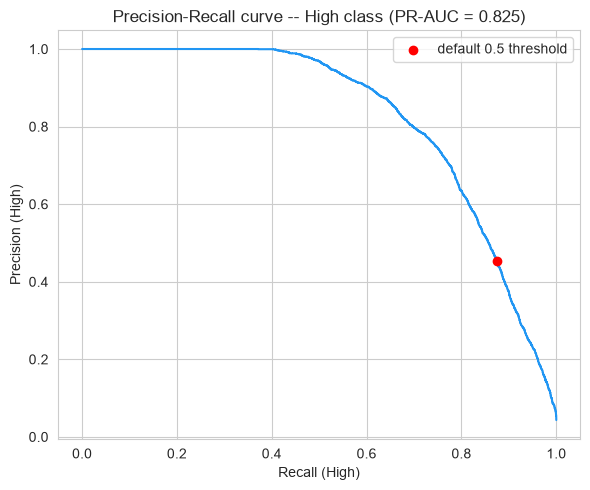


If the curve shows a threshold that meaningfully raises precision while recall stays usable,
carry that insight into Section 8's final threshold tuning below.


In [9]:
probs_q = quick_rf.predict_proba(X_te_q)[:, 1]
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_te_q, probs_q)
ap_q = average_precision_score(y_te_q, probs_q)

print(f"PR-AUC (average precision) at this quick pass: {ap_q:.3f}\n")
print(f"{'threshold':>10}  {'precision':>10}  {'recall':>8}")
for target_prec in [0.60, 0.70, 0.75, 0.80, 0.85, 0.90]:
    hits = np.where(prec_arr[:-1] >= target_prec)[0]
    if len(hits) == 0:
        print(f"{'--':>10}  {'n/a':>10}  precision {target_prec:.2f} not reachable at any threshold")
        continue
    idx = hits[0]
    print(f"{thresh_arr[idx]:>10.3f}  {prec_arr[idx]:>10.3f}  {rec_arr[idx]:>8.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rec_arr, prec_arr, color='#2196F3')
ax.scatter(rec[0], prec[0], color='red', zorder=5, label='default 0.5 threshold')
ax.set_xlabel('Recall (High)')
ax.set_ylabel('Precision (High)')
ax.set_title(f'Precision-Recall curve -- High class (PR-AUC = {ap_q:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig('pr_curve_quick_check.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nIf the curve shows a threshold that meaningfully raises precision while recall stays usable,")
print("carry that insight into Section 8's final threshold tuning below.")

---
## TEST CELL 4 — Boundary-Zone Feature Audit  *(eyeball before proceeding)*

The old Medium class sat between 0.5ms and 1.5ms and was the weak point in v6 (recall 0.380, mostly confused
with Normal). Now that Medium is folded into Not-High, check whether that same near-boundary zone
(0.5ms <= avg_stall_ns < 1.5ms) still looks meaningfully different from High on the top features -- or whether
it looks closer to High than the clearly-normal rows do, which would explain any false positives/negatives
clustering near the boundary rather than a resampling or threshold problem.

In [10]:
boundary_zone   = df[(df['avg_stall_ns'] >= 500_000) & (df['avg_stall_ns'] < HIGH_THRESHOLD_NS)]
clearly_normal  = df[df['avg_stall_ns'] < 500_000]
high_rows       = df[df['y'] == 1]

audit_features = ['cpu_migrations', 'runtime_per_switch']

print(f"{'feature':<20} {'clearly_normal':>15} {'boundary_zone':>15} {'high':>12}   p(boundary~high)  p(normal~high)")
for feat in audit_features:
    med_cn = clearly_normal[feat].median()
    med_bz = boundary_zone[feat].median()
    med_hi = high_rows[feat].median()
    _, p_bz_hi = mannwhitneyu(boundary_zone[feat], high_rows[feat], alternative='two-sided')
    _, p_cn_hi = mannwhitneyu(clearly_normal[feat], high_rows[feat], alternative='two-sided')
    print(f"{feat:<20} {med_cn:>15.2f} {med_bz:>15.2f} {med_hi:>12.2f}   {p_bz_hi:>16.4g}  {p_cn_hi:>15.4g}")

print("\nIf boundary_zone's median sits meaningfully closer to high's than clearly_normal's does (and the")
print("Mann-Whitney p-value for boundary~high is much larger, i.e. less distinguishable, than normal~high),")
print("that overlap is a real signal-level limit -- not something more resampling or threshold tuning fixes.")
print("It points instead at needing a new discriminative feature, per v6's own 'next steps' note.")

feature               clearly_normal   boundary_zone         high   p(boundary~high)  p(normal~high)
cpu_migrations                  1.00            1.00       128.00                  0                0
runtime_per_switch          74321.22       102643.82   2354757.97                  0                0

If boundary_zone's median sits meaningfully closer to high's than clearly_normal's does (and the
Mann-Whitney p-value for boundary~high is much larger, i.e. less distinguishable, than normal~high),
that overlap is a real signal-level limit -- not something more resampling or threshold tuning fixes.
It points instead at needing a new discriminative feature, per v6's own 'next steps' note.


---
### STOP — review TEST CELLS 1-4 above before continuing

If the threshold grid looks sane, binary framing is competitive with (or better than) v6's isolated High
numbers, a usable precision/recall trade-off exists, and the boundary-zone audit doesn't reveal a hard
signal-level ceiling -- proceed to the pipeline below. Otherwise, adjust `HIGH_THRESHOLD_NS` above and re-run
from TEST CELL 1, or reconsider whether binary framing is the right call, before committing further compute.

In [11]:
del quick_rf, quick_pred, probs_q, prec_arr, rec_arr, thresh_arr
gc.collect()

70

---
# Section 3 — Stratified Train/Test Split (Frozen)

Same discipline as v6: this split is frozen and never touched by resampling, scaling, or threshold tuning below.

In [12]:
X = df[FEATURE_COLS].fillna(0)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

test_context = df.loc[X_test.index, ['comm', 'session_label', 'avg_stall_ns', 'max_stall_ns']]

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows (frozen)\n")
print("Class distribution -- Train:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(1).to_string())
print("\nClass distribution -- Test:")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(1).to_string())

Train: 531404 rows | Test: 132852 rows (frozen)

Class distribution -- Train:
y
0   95.700
1    4.300

Class distribution -- Test:
y
0   95.700
1    4.300


---
# Section 4 — Class Imbalance: Baseline vs `class_weight` vs SMOTE vs Borderline-SMOTE vs ADASYN

Same five strategies as v6, same fixed RF architecture, now scored on the binary High class specifically
(precision/recall/F1 for High, plus PR-AUC and ROC-AUC since we now have well-defined positive-class
probabilities to work with).

In [13]:
try:
    from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
    HAS_IMBLEARN = True
except ImportError:
    print("imbalanced-learn not installed. Run: pip install imbalanced-learn --break-system-packages")
    HAS_IMBLEARN = False

In [14]:
def evaluate_predictions(y_true, y_pred, y_proba, name):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=TARGET_LABELS, zero_division=0
    )
    macro_f1 = f1.mean()
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    result = {
        'strategy': name,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'precision_high': prec[1],
        'recall_high': rec[1],
        'f1_high': f1[1],
    }
    if y_proba is not None:
        result['pr_auc_high'] = average_precision_score(y_true, y_proba)
        result['roc_auc_high'] = roc_auc_score(y_true, y_proba)
    return result

imbalance_results = []
imbalance_models = {}
confusion_matrices = {}

# 1. Baseline -- no resampling, no class weighting
rf_baseline = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=5, class_weight=None,
    n_jobs=4, random_state=RANDOM_STATE
)
rf_baseline.fit(X_train, y_train)
pred = rf_baseline.predict(X_test)
proba = rf_baseline.predict_proba(X_test)[:, 1]
imbalance_results.append(evaluate_predictions(y_test, pred, proba, 'Baseline (no handling)'))
confusion_matrices['Baseline (no handling)'] = confusion_matrix(y_test, pred, labels=TARGET_LABELS)
imbalance_models['Baseline (no handling)'] = rf_baseline
del rf_baseline, pred, proba; gc.collect()

# 2. class_weight='balanced'
rf_balanced = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=5, class_weight='balanced',
    n_jobs=4, random_state=RANDOM_STATE
)
rf_balanced.fit(X_train, y_train)
pred = rf_balanced.predict(X_test)
proba = rf_balanced.predict_proba(X_test)[:, 1]
imbalance_results.append(evaluate_predictions(y_test, pred, proba, "class_weight=balanced"))
confusion_matrices["class_weight=balanced"] = confusion_matrix(y_test, pred, labels=TARGET_LABELS)
imbalance_models["class_weight=balanced"] = rf_balanced
del rf_balanced, pred, proba; gc.collect()

resamplers = {}
if HAS_IMBLEARN:
    resamplers = {
        'SMOTE': SMOTE(random_state=RANDOM_STATE),
        'Borderline-SMOTE': BorderlineSMOTE(random_state=RANDOM_STATE),
        'ADASYN': ADASYN(random_state=RANDOM_STATE),
    }
    for name, resampler in resamplers.items():
        X_res, y_res = resampler.fit_resample(X_train, y_train)
        rf_res = RandomForestClassifier(
            n_estimators=300, min_samples_leaf=5, class_weight=None,
            n_jobs=4, random_state=RANDOM_STATE
        )
        rf_res.fit(X_res, y_res)
        pred = rf_res.predict(X_test)
        proba = rf_res.predict_proba(X_test)[:, 1]
        imbalance_results.append(evaluate_predictions(y_test, pred, proba, name))
        confusion_matrices[name] = confusion_matrix(y_test, pred, labels=TARGET_LABELS)
        imbalance_models[name] = rf_res
        del X_res, y_res, rf_res, pred, proba; gc.collect()
else:
    print("Skipped resampling strategies -- imbalanced-learn not installed.")

imbalance_df = pd.DataFrame(imbalance_results).set_index('strategy')
imbalance_df.round(3)

,accuracy,macro_f1,weighted_f1,precision_high,recall_high,f1_high,pr_auc_high,roc_auc_high
strategy,,,,,,,,
Baseline (no handling),0.981,0.865,0.979,0.888,0.634,0.740,0.830,0.974
class_weight=balanced,0.949,0.784,0.956,0.452,0.875,0.596,0.825,0.975
SMOTE,0.975,0.856,0.975,0.683,0.771,0.724,0.817,0.972
Borderline-SMOTE,0.974,0.854,0.975,0.675,0.773,0.721,0.815,0.971
ADASYN,0.970,0.840,0.972,0.621,0.789,0.695,0.810,0.971


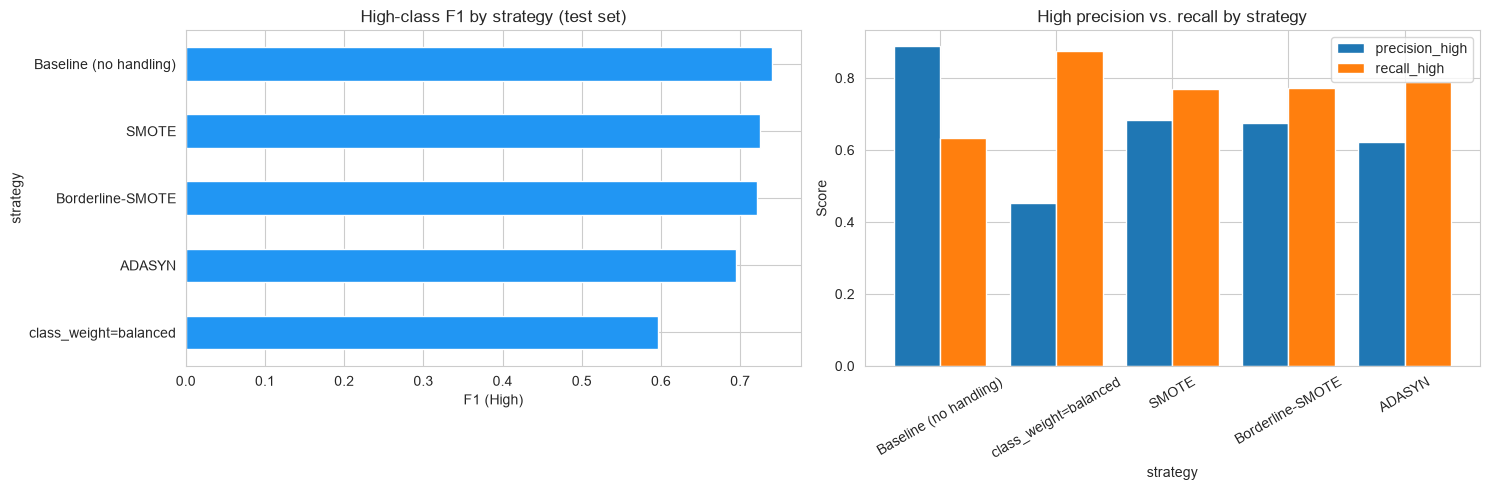


Best strategy by High-class F1: 'Baseline (no handling)' (F1=0.740, precision=0.888, recall=0.634)


In [15]:
# -- Visual comparison ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

imbalance_df['f1_high'].sort_values().plot(kind='barh', ax=axes[0], color='#2196F3', edgecolor='white')
axes[0].set_title('High-class F1 by strategy (test set)')
axes[0].set_xlabel('F1 (High)')

imbalance_df[['precision_high', 'recall_high']].plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('High precision vs. recall by strategy')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('imbalance_strategy_comparison_v7.png', dpi=150, bbox_inches='tight')
plt.show()

best_strategy = imbalance_df['f1_high'].idxmax()
print(f"\nBest strategy by High-class F1: '{best_strategy}' (F1={imbalance_df.loc[best_strategy, 'f1_high']:.3f}, "
      f"precision={imbalance_df.loc[best_strategy, 'precision_high']:.3f}, "
      f"recall={imbalance_df.loc[best_strategy, 'recall_high']:.3f})")

---
# Section 5 — Stratified K-Fold CV Robustness Check

v6 evaluated everything on a single 80/20 split. Before the best strategy above goes into the champion artifact,
confirm its High-class F1 isn't just a lucky split: run 5-fold stratified CV with the resampler correctly
scoped inside each fold (via an imblearn `Pipeline`, so synthetic points never leak across the fold boundary).

In [16]:
from imblearn.pipeline import Pipeline as ImbPipeline

f1_high_scorer = make_scorer(f1_score, pos_label=1, zero_division=0)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

if HAS_IMBLEARN and best_strategy in resamplers:
    cv_pipeline = ImbPipeline([
        ('resample', resamplers[best_strategy]),
        ('clf', RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight=None,
                                        n_jobs=4, random_state=RANDOM_STATE)),
    ])
else:
    class_weight = 'balanced' if best_strategy == 'class_weight=balanced' else None
    cv_pipeline = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight=class_weight,
                                          n_jobs=4, random_state=RANDOM_STATE)

cv_scores = cross_val_score(cv_pipeline, X_train, y_train, cv=skf, scoring=f1_high_scorer, n_jobs=1)

print(f"5-fold CV High-class F1 for '{best_strategy}': {cv_scores.round(3).tolist()}")
print(f"  mean = {cv_scores.mean():.3f}   std = {cv_scores.std():.3f}")
print(f"  single-split High F1 was {imbalance_df.loc[best_strategy, 'f1_high']:.3f}")
print("\nIf the single-split number falls within roughly one std of the CV mean, it's not split-lucky and")
print("it's safe to proceed with hyperparameter search below. A big gap means re-check the split or investigate")
print("session_label leakage between train/test (e.g. the same process instance split across both).")

5-fold CV High-class F1 for 'Baseline (no handling)': [0.742, 0.736, 0.731, 0.724, 0.732]
  mean = 0.733   std = 0.006
  single-split High F1 was 0.740

If the single-split number falls within roughly one std of the CV mean, it's not split-lucky and
it's safe to proceed with hyperparameter search below. A big gap means re-check the split or investigate
session_label leakage between train/test (e.g. the same process instance split across both).


---
# Section 6 — Light Hyperparameter Search

Only now, after imbalance handling and the threshold lever have already been checked (Sections 4-5, TEST 3) --
tuning a reasonable RF further is a smaller lever than those and not worth spending compute on first.
Small grid, scored on High-class F1, reusing the winning resampling strategy.

In [17]:
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 12, 20],
    'min_samples_leaf': [1, 5, 10],
}

if HAS_IMBLEARN and best_strategy in resamplers:
    X_train_search, y_train_search = resamplers[best_strategy].fit_resample(X_train, y_train)
    class_weight = None
else:
    X_train_search, y_train_search = X_train, y_train
    class_weight = 'balanced' if best_strategy == 'class_weight=balanced' else None

base_rf = RandomForestClassifier(class_weight=class_weight, n_jobs=4, random_state=RANDOM_STATE)
grid_search = GridSearchCV(
    base_rf, param_grid, scoring=f1_high_scorer, cv=3, n_jobs=1, refit=True
)
grid_search.fit(X_train_search, y_train_search)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV High-class F1: {grid_search.best_score_:.3f}")

tuned_model = grid_search.best_estimator_
tuned_pred = tuned_model.predict(X_test)
tuned_proba = tuned_model.predict_proba(X_test)[:, 1]
tuned_result = evaluate_predictions(y_test, tuned_pred, tuned_proba, f'Tuned ({best_strategy})')
print(f"\nTuned model on frozen test set: precision={tuned_result['precision_high']:.3f}, "
      f"recall={tuned_result['recall_high']:.3f}, F1={tuned_result['f1_high']:.3f}")

del X_train_search, y_train_search, tuned_pred; gc.collect()

Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 500}
Best CV High-class F1: 0.737

Tuned model on frozen test set: precision=0.882, recall=0.642, F1=0.743


471

---
# Section 7 — Feature Importance: Impurity vs Permutation vs SHAP

Same triangulation as v6, computed on `tuned_model`.

In [18]:
impurity_importance = pd.Series(tuned_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print("Top 10 -- impurity-based importance:")
print(impurity_importance.head(10).round(4).to_string())

Top 10 -- impurity-based importance:
log_total_runtime_ns   0.174
runtime_per_switch     0.129
cpu_migrations         0.102
involuntary_switches   0.082
voluntary_ratio        0.073
involuntary_ratio      0.073
ctx_switches           0.063
voluntary_switches     0.054
minor_faults           0.030
avg_mutex_wait_ns      0.029


In [19]:
perm_result = permutation_importance(
    tuned_model, X_test, y_test, scoring='f1', n_repeats=5,
    random_state=RANDOM_STATE, n_jobs=1
)
permutation_importance_s = pd.Series(perm_result.importances_mean, index=FEATURE_COLS).sort_values(ascending=False)
print("Top 10 -- permutation importance (F1 drop when shuffled):")
print(permutation_importance_s.head(10).round(4).to_string())

Top 10 -- permutation importance (F1 drop when shuffled):
runtime_per_switch       0.497
cpu_migrations           0.360
minor_faults             0.056
voluntary_ratio          0.027
involuntary_ratio        0.023
log_total_runtime_ns     0.022
rwsem_read_contentions   0.014
lock_pressure            0.012
involuntary_switches     0.010
ctx_switches             0.008


In [20]:
try:
    import shap
    HAS_SHAP = True
    explainer = shap.TreeExplainer(tuned_model)
    shap_sample = X_test.sample(min(200, len(X_test)), random_state=RANDOM_STATE)
    shap_values = explainer.shap_values(shap_sample, check_additivity=False)

    if isinstance(shap_values, list):
        mean_abs_shap = np.abs(shap_values[1]).mean(axis=0)   # class-1 (High) SHAP values
    elif shap_values.ndim == 3:
        mean_abs_shap = np.abs(shap_values[:, :, 1]).mean(axis=0)
    else:
        mean_abs_shap = np.abs(shap_values).mean(axis=0)
    shap_importance = pd.Series(mean_abs_shap, index=FEATURE_COLS).sort_values(ascending=False)
    print("Top 10 -- SHAP mean |value| for the High class:")
    print(shap_importance.head(10).round(4).to_string())
except ImportError:
    print("shap not installed. Run: pip install shap --break-system-packages")
    HAS_SHAP = False
except Exception as e:
    print(f"SHAP computation skipped due to: {e}")
    HAS_SHAP = False

Top 10 -- SHAP mean |value| for the High class:
runtime_per_switch       0.023
cpu_migrations           0.017
involuntary_ratio        0.012
log_total_runtime_ns     0.011
voluntary_ratio          0.011
ctx_switches             0.010
voluntary_switches       0.009
involuntary_switches     0.007
minor_faults             0.006
rwsem_read_contentions   0.004


In [21]:
top_n = 12
comparison = pd.DataFrame({
    'impurity_rank': impurity_importance.rank(ascending=False),
    'permutation_rank': permutation_importance_s.rank(ascending=False),
})
if HAS_SHAP:
    comparison['shap_rank'] = shap_importance.rank(ascending=False)

comparison['avg_rank'] = comparison.mean(axis=1)
comparison = comparison.sort_values('avg_rank').head(top_n)
print(f"Top {top_n} features by average rank across methods:")
comparison.round(1)

Top 12 features by average rank across methods:


,impurity_rank,permutation_rank,shap_rank,avg_rank
runtime_per_switch,2.000,1.000,1.000,1.300
cpu_migrations,3.000,2.000,2.000,2.300
log_total_runtime_ns,1.000,6.000,4.000,3.700
involuntary_ratio,6.000,5.000,3.000,4.700
voluntary_ratio,5.000,4.000,5.000,4.700
minor_faults,9.000,3.000,9.000,7.000
involuntary_switches,4.000,9.000,8.000,7.000
ctx_switches,7.000,10.000,6.000,7.700
voluntary_switches,8.000,14.000,7.000,9.700
rwsem_read_contentions,14.000,7.000,10.000,10.300


---
# Section 8 — Final Decision-Threshold Tuning + Confusion Matrix + Misclassified Inspection

TEST CELL 3 showed whether a non-default threshold is worth it on a quick model; now do it properly on
`tuned_model` and pick the deployment cutoff.

PR-AUC: 0.831   ROC-AUC: 0.975

 threshold   precision    recall
     0.136       0.600     0.825
     0.218       0.700     0.783
     0.279       0.750     0.754
     0.340       0.800     0.717
     0.417       0.850     0.676
     0.551       0.900     0.621


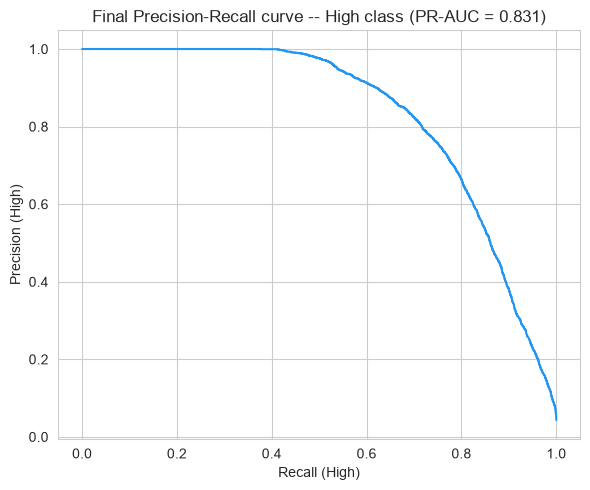


Using DECISION_THRESHOLD = 0.5
              precision    recall  f1-score   support

    Not-High       0.98      1.00      0.99    127091
        High       0.88      0.64      0.74      5761

    accuracy                           0.98    132852
   macro avg       0.93      0.82      0.87    132852
weighted avg       0.98      0.98      0.98    132852



In [22]:
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test, tuned_proba)
ap = average_precision_score(y_test, tuned_proba)
roc_auc = roc_auc_score(y_test, tuned_proba)
print(f"PR-AUC: {ap:.3f}   ROC-AUC: {roc_auc:.3f}\n")

print(f"{'threshold':>10}  {'precision':>10}  {'recall':>8}")
for target_prec in [0.60, 0.70, 0.75, 0.80, 0.85, 0.90]:
    hits = np.where(prec_arr[:-1] >= target_prec)[0]
    if len(hits) == 0:
        continue
    idx = hits[0]
    print(f"{thresh_arr[idx]:>10.3f}  {prec_arr[idx]:>10.3f}  {rec_arr[idx]:>8.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rec_arr, prec_arr, color='#2196F3')
ax.set_xlabel('Recall (High)')
ax.set_ylabel('Precision (High)')
ax.set_title(f'Final Precision-Recall curve -- High class (PR-AUC = {ap:.3f})')
plt.tight_layout()
plt.savefig('pr_curve_final.png', dpi=150, bbox_inches='tight')
plt.show()

# -- Set the deployment threshold here, informed by the table above -----------
DECISION_THRESHOLD = 0.5   # change based on the precision/recall trade-off printed above
y_pred_final = (tuned_proba >= DECISION_THRESHOLD).astype(int)

print(f"\nUsing DECISION_THRESHOLD = {DECISION_THRESHOLD}")
print(classification_report(y_test, y_pred_final, labels=TARGET_LABELS, target_names=TARGET_NAMES, zero_division=0))

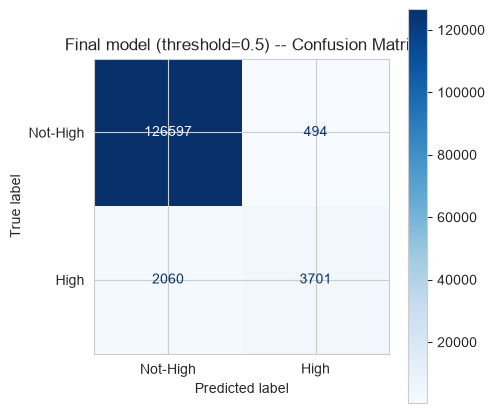

[[126597    494]
 [  2060   3701]]


In [23]:
cm = confusion_matrix(y_test, y_pred_final, labels=TARGET_LABELS)
fig, ax = plt.subplots(figsize=(5, 4.5))
disp = ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Final model (threshold={DECISION_THRESHOLD}) -- Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix_v7.png', dpi=150, bbox_inches='tight')
plt.show()
print(cm)

In [24]:
# -- Sample misclassified rows, separated into false positives / false negatives
N_SAMPLES = 35

fp_mask = (y_pred_final == 1) & (y_test.values == 0)
fn_mask = (y_pred_final == 0) & (y_test.values == 1)

fp_idx = X_test.index[fp_mask]
fn_idx = X_test.index[fn_mask]

def build_view(idx, kind):
    view = pd.DataFrame(index=idx)
    view['error_type'] = kind
    view['comm'] = test_context.loc[idx, 'comm']
    view['session_label'] = test_context.loc[idx, 'session_label']
    view['avg_stall_ns_ms'] = test_context.loc[idx, 'avg_stall_ns'] / 1e6
    for feat in comparison.index[:5]:
        view[feat] = X_test.loc[idx, feat]
    return view

fp_sample = build_view(fp_idx, 'False Positive (predicted High, actually not)').sample(
    min(N_SAMPLES // 2, len(fp_idx)), random_state=RANDOM_STATE
) if len(fp_idx) else pd.DataFrame()
fn_sample = build_view(fn_idx, 'False Negative (predicted not-High, actually High)').sample(
    min(N_SAMPLES // 2, len(fn_idx)), random_state=RANDOM_STATE
) if len(fn_idx) else pd.DataFrame()

print(f"False positives: {fp_mask.sum()} / {len(y_test)}   False negatives: {fn_mask.sum()} / {len(y_test)}\n")
misclassified_sample = pd.concat([fp_sample, fn_sample])
misclassified_sample.round(3)

False positives: 494 / 132852   False negatives: 2060 / 132852



,error_type,comm,session_label,avg_stall_ns_ms,runtime_per_switch,cpu_migrations,log_total_runtime_ns,involuntary_ratio,voluntary_ratio
775586,"False Positive (predicted High, actually not)",stress-ng-strea,stream_memory_contention,0.713,3094818.000,252.000,24.297,1.000,0.000
458705,"False Positive (predicted High, actually not)",stress-ng-cpu,stream_memory_contention,0.160,3519915.500,293.000,24.205,1.000,0.000
384002,"False Positive (predicted High, actually not)",stress-ng-strea,stream_memory_contention,1.175,3511915.500,199.000,23.934,0.999,0.001
620311,"False Positive (predicted High, actually not)",stress-ng-strea,stream_memory_contention,0.912,3453600.750,238.000,24.254,0.999,0.001
509326,"False Positive (predicted High, actually not)",stress-ng-cache,cache_contention,0.055,2666067.000,148.000,23.594,1.000,0.000
620428,"False Positive (predicted High, actually not)",stress-ng-cpu,stream_memory_contention,0.151,3598471.250,386.000,24.469,1.000,0.000
668757,"False Positive (predicted High, actually not)",stress-ng-strea,stream_memory_contention,0.336,3774148.250,287.000,24.365,1.000,0.000
662489,"False Positive (predicted High, actually not)",stress-ng-strea,stream_memory_contention,0.700,3255281.000,189.000,24.206,1.000,0.000
618373,"False Positive (predicted High, actually not)",sleep,stream_memory_contention,0.012,760384.375,1.000,15.151,0.800,0.200
558913,"False Positive (predicted High, actually not)",stress-ng-strea,cache_contention,0.779,3455786.500,394.000,24.369,0.996,0.004


---
# Section 9 — Final Comparison, Champion Selection & Artifact Saving

In [25]:
final_comparison = pd.concat([
    imbalance_df,
    pd.DataFrame([tuned_result]).set_index('strategy')
]).round(3)
final_comparison = final_comparison.sort_values('f1_high', ascending=False)
print("Final strategy comparison, best High-class F1 first:")
final_comparison

Final strategy comparison, best High-class F1 first:


,accuracy,macro_f1,weighted_f1,precision_high,recall_high,f1_high,pr_auc_high,roc_auc_high
strategy,,,,,,,,
Tuned (Baseline (no handling)),0.981,0.867,0.979,0.882,0.642,0.743,0.831,0.975
Baseline (no handling),0.981,0.865,0.979,0.888,0.634,0.740,0.830,0.974
SMOTE,0.975,0.856,0.975,0.683,0.771,0.724,0.817,0.972
Borderline-SMOTE,0.974,0.854,0.975,0.675,0.773,0.721,0.815,0.971
ADASYN,0.970,0.840,0.972,0.621,0.789,0.695,0.810,0.971
class_weight=balanced,0.949,0.784,0.956,0.452,0.875,0.596,0.825,0.975


In [26]:
overall_champion_name = final_comparison.index[0]
overall_champion = tuned_model if overall_champion_name.startswith('Tuned') else imbalance_models.get(overall_champion_name)

print(f"Champion: '{overall_champion_name}'")
print(f"  High precision : {final_comparison.loc[overall_champion_name, 'precision_high']:.3f}  (v6 3-class isolated High: 0.690)")
print(f"  High recall    : {final_comparison.loc[overall_champion_name, 'recall_high']:.3f}  (v6 3-class isolated High: 0.763)")
print(f"  High F1        : {final_comparison.loc[overall_champion_name, 'f1_high']:.3f}  (v6 3-class isolated High: 0.730)")
if 'pr_auc_high' in final_comparison.columns:
    print(f"  PR-AUC         : {final_comparison.loc[overall_champion_name, 'pr_auc_high']:.3f}")

Champion: 'Tuned (Baseline (no handling))'
  High precision : 0.882  (v6 3-class isolated High: 0.690)
  High recall    : 0.642  (v6 3-class isolated High: 0.763)
  High F1        : 0.743  (v6 3-class isolated High: 0.730)
  PR-AUC         : 0.831


In [27]:
import joblib

joblib.dump(overall_champion, 'champion_model_v7.pkl')
print("Saved: champion_model_v7.pkl")

with open('feature_cols_v7.json', 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)
print("Saved: feature_cols_v7.json")

with open('label_thresholds_v7.json', 'w') as f:
    json.dump(
        {
            'high_threshold_ns': HIGH_THRESHOLD_NS,
            'decision_probability_threshold': DECISION_THRESHOLD,
        },
        f, indent=2
    )
print("Saved: label_thresholds_v7.json  (binary High cutoff + deployment probability threshold)")

final_comparison.to_csv('strategy_comparison_v7.csv')
print("Saved: strategy_comparison_v7.csv")

Saved: champion_model_v7.pkl
Saved: feature_cols_v7.json
Saved: label_thresholds_v7.json  (binary High cutoff + deployment probability threshold)
Saved: strategy_comparison_v7.csv


## Summary

- **Threshold calibration** (TEST 1): built the percentile ladder + candidate-cutoff grid v6's markdown promised
  but never ran, so `HIGH_THRESHOLD_NS` is picked with the actual distribution visible, not blind.
- **Binary reframe** (Section 2, TEST 2): High vs. Not-High, checked against v6's isolated High precision/recall
  before being adopted as the primary track -- not assumed to be better by default.
- **Decision threshold** (TEST 3, Section 8): swept `predict_proba` cutoffs on both a quick model and the final
  tuned one, so the deployed `DECISION_THRESHOLD` is chosen from an actual precision/recall trade-off curve,
  not left at the default 0.5.
- **Boundary-zone audit** (TEST 4): checked whether the old Medium-range rows (0.5-1.5ms) still look
  meaningfully different from High on `cpu_migrations` / `runtime_per_switch`, or whether that's a real
  signal-level ceiling rather than something resampling/threshold fixes can close.
- **Imbalance handling** (Section 4): same five strategies as v6 (baseline, class_weight, SMOTE,
  Borderline-SMOTE, ADASYN), now scored on High-class precision/recall/F1/PR-AUC directly instead of macro
  metrics across three classes.
- **CV robustness check** (Section 5): 5-fold stratified CV on the winning strategy, resampler correctly scoped
  inside each fold via an imblearn `Pipeline`, to confirm the single-split number wasn't split-lucky.
- **Hyperparameter search** (Section 6): light grid search, run only after the bigger imbalance/threshold levers
  were already checked.
- **Feature importance** (Section 7): impurity, permutation, and SHAP triangulated for the High class
  specifically (not averaged across three classes like v6).
- **Misclassified inspection** (Section 8): false positives and false negatives sampled and shown separately,
  since in a binary High-detection problem they represent different failure modes (false alarms vs. missed
  bottlenecks) rather than "adjacent class confusion."

**Next steps if High precision/recall are still not where you need them:** re-check TEST CELL 4's boundary-zone
audit output -- if the near-boundary rows are statistically indistinguishable from High on the current top
features, the next lever is a new discriminative feature (e.g. a ratio or rate-of-change signal), not further
resampling or threshold tuning on the current feature set.